# 01a — LendingClub EDA: two files, one funnel, one trap

Narrated exploration of the LendingClub loan data (2007-2018Q4), for a reader who has never
touched it. The fitting notebook (`01_lendingclub.ipynb`) extracts consumer/lead parameters;
this one establishes what the data is, what each file can and cannot say, and the leakage trap
buried in the wide file. Read-only: no artifacts, no mutations (spec Section 0, v0.4).

Provenance: HD — per the EDA-companion convention (P-006, INT-012).

## The one mental model that unlocks this dataset

**LendingClub was a peer-to-peer lender, and this dataset is its application funnel split into
two very unequal halves.** People applied for personal loans online; LendingClub underwrote
them; ~7.6% were accepted and funded, the rest declined. The two files are those two
populations:

- **`accepted` (~2.26M rows, 151 columns):** funded loans, in full underwriting detail —
  amount, purpose, income, FICO, DTI, employment — *plus everything that happened afterward*
  (payments, delinquency, charge-offs, settlements). Rich, but survivors only.
- **`rejected` (~27.6M rows, 9 columns):** declined applications, recorded thinly — amount,
  date, a risk score, DTI, geography, employment length. Twelve times the people, a tenth of
  the detail.

Two consequences drive everything downstream:

1. **Survivorship bias.** The accepted file alone describes people a lender already liked. A
   lead marketplace sees *applicants* — closer to accepted + rejected pooled — which is why
   the fitting notebook widens the `loan_amnt`/`dti` tails with the rejected file (C8) and
   fits the lead-quality score `q` on the accept/reject boundary itself.
2. **The leakage trap.** Most of the accepted file's 151 columns describe *outcomes* — things
   knowable only after origination. Any model of application-time quality that touches them is
   cheating. The census below counts exactly how much of the file is off-limits.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
ROOT = Path.cwd().resolve().parents[1]
assert (ROOT / "pyproject.toml").exists()
RAW = ROOT / "data" / "raw" / "lendingclub"

# Population totals are established facts from the fitting artifact — cited, not re-derived
# (spec Section 0). The rejected file is re-sampled here only for distribution profiling.
LC = json.loads((ROOT / "simulation" / "params" / "lendingclub_marginals.json").read_text())
N_ACC = LC["metadata"]["sources"]["accepted"]["rows"]
N_REJ = LC["metadata"]["sources"]["rejected"]["rows"]
print(f"accepted: {N_ACC:,} rows   rejected: {N_REJ:,} rows   "
      f"acceptance rate: {LC['metadata']['acceptance_rate']:.2%}")


accepted: 2,260,668 rows   rejected: 27,648,741 rows   acceptance rate: 7.56%


## 1. The 151-column census — and the leakage boundary

Rather than a 151-row dictionary, the honest structure is a census by column family: which
columns describe the *application* (usable for application-time modeling) versus the *loan's
later life* (leakage for our purposes). Family assignment is by name pattern and is itself an
assumption, stated here and checkable from the printed membership.


In [2]:
header = pd.read_csv(RAW / "accepted_2007_to_2018Q4.csv.gz", nrows=0)
all_cols = list(header.columns)

FAMILIES = {
    "identity/bookkeeping": ["id", "member_id", "url", "policy_code"],
    "application: loan ask": ["loan_amnt", "term", "purpose", "title", "desc",
                               "application_type", "issue_d"],
    "application: borrower profile": ["emp_title", "emp_length", "home_ownership",
                                       "annual_inc", "verification_status", "addr_state",
                                       "zip_code", "dti", "fico_range_low", "fico_range_high"],
    "application: credit history": [c for c in all_cols if c.startswith(("delinq_", "inq_",
        "mths_since_", "open_", "pub_rec", "revol_", "total_acc", "acc_", "mo_sin", "mort_acc",
        "num_", "pct_tl", "percent_bc", "tot_", "total_", "bc_", "avg_cur_bal", "annual_inc_j",
        "dti_joint", "verification_status_joint", "revol", "earliest_cr_line", "chargeoff_within",
        "collections_12", "tax_liens", "il_util", "all_util", "max_bal_bc", "open_acc", "inq_fi",
        "inq_last"))],
    "pricing (set at origination)": ["int_rate", "installment", "grade", "sub_grade",
                                      "funded_amnt", "funded_amnt_inv", "initial_list_status",
                                      "disbursement_method"],
    "OUTCOME: status & payments": [c for c in all_cols if c.startswith(("loan_status",
        "out_prncp", "total_pymnt", "total_rec", "recoveries", "collection_recovery",
        "last_pymnt", "next_pymnt", "last_credit_pull", "last_fico", "pymnt_plan"))],
    "OUTCOME: hardship & settlement": [c for c in all_cols if c.startswith(("hardship",
        "settlement", "debt_settlement", "deferral", "payment_plan_start", "orig_projected"))],
    "secondary market": [c for c in all_cols if c.startswith("sec_app")],
}
assigned = set()
rows = []
for fam, cols in FAMILIES.items():
    cols = [c for c in cols if c in all_cols and c not in assigned]
    assigned.update(cols)
    rows.append((fam, len(cols)))
rows.append(("(unassigned by the patterns above)", len(set(all_cols) - assigned)))
census = pd.DataFrame(rows, columns=["column family", "n_columns"])
print(census.to_string(index=False))
outcome_n = sum(n for f, n in rows if f.startswith("OUTCOME"))
print(f"\ntotal columns: {len(all_cols)}; outcome/leakage columns: {outcome_n} "
      f"({outcome_n/len(all_cols):.0%} of the file)")
print("unassigned:", sorted(set(all_cols) - assigned))


                     column family  n_columns
              identity/bookkeeping          4
             application: loan ask          7
     application: borrower profile         10
       application: credit history         76
      pricing (set at origination)          8
        OUTCOME: status & payments         12
    OUTCOME: hardship & settlement         22
                  secondary market         12
(unassigned by the patterns above)          0

total columns: 151; outcome/leakage columns: 34 (23% of the file)
unassigned: []


## 2. The rejected file: complete data dictionary

Nine columns — small enough to document exhaustively. Distinct/null counts from a seeded
15% sample (~4.1M rows) to keep memory sane; the mapping to accepted-file names is the one
the fitting notebook documents.


In [3]:
rej_parts = []
for chunk in pd.read_csv(RAW / "rejected_2007_to_2018Q4.csv.gz", chunksize=2_000_000):
    rej_parts.append(chunk.sample(frac=0.15, random_state=SEED))
rej = pd.concat(rej_parts, ignore_index=True)
del rej_parts
REJ_DEFS = {
    "Amount Requested": "Loan amount applied for (maps to accepted loan_amnt)",
    "Application Date": "Date of the declined application",
    "Loan Title": "Applicant's free-text purpose (unstructured cousin of accepted purpose)",
    "Risk_Score": "Credit score at application (FICO-like; heavily null in later vintages)",
    "Debt-To-Income Ratio": "DTI as a percent-string; negative values are a missing sentinel",
    "Zip Code": "First 3 digits + xx",
    "State": "US state (maps to addr_state)",
    "Employment Length": "Same ordinal buckets as accepted emp_length",
    "Policy Code": "1 = public product, 2 = other/undocumented policy",
}
dictionary = pd.DataFrame(
    [(c, str(rej[c].dtype), rej[c].nunique(), round(rej[c].isna().mean()*100, 2), REJ_DEFS[c])
     for c in rej.columns],
    columns=["column", "dtype", "distinct", "null_pct", "definition"])
pd.set_option("display.max_colwidth", 100)
dictionary


,column,dtype,distinct,null_pct,definition
0,Amount Requested,float64,2392,0.00,Loan amount applied for (maps to accepted loan_amnt)
1,Application Date,str,4196,0.00,Date of the declined application
2,Loan Title,str,13553,0.00,Applicant's free-text purpose (unstructured cousin of accepted purpose)
3,Risk_Score,float64,677,66.90,Credit score at application (FICO-like; heavily null in later vintages)
4,Debt-To-Income Ratio,str,56261,0.00,DTI as a percent-string; negative values are a missing sentinel
5,Zip Code,str,997,0.00,First 3 digits + xx
6,State,str,51,0.00,US state (maps to addr_state)
7,Employment Length,str,11,3.44,Same ordinal buckets as accepted emp_length
8,Policy Code,float64,2,0.00,"1 = public product, 2 = other/undocumented policy"


`Risk_Score` deserves a highlight: its null share is enormous because LendingClub stopped
recording it for later vintages — missingness here is a *time* artifact, not applicant
behavior. This is why the fitting notebook's acceptance model uses only the features both
files share cleanly (amount, DTI, employment) and leaves `Risk_Score` out.


## 3. The accepted file: profiled columns, sample, and semantics

The fitting notebook uses eight application-time columns; here they are with the same
dictionary treatment, on the full accepted file.


In [4]:
ACC_COLS = ["loan_amnt", "purpose", "emp_length", "dti", "fico_range_low", "fico_range_high",
            "addr_state", "annual_inc", "issue_d", "grade", "sub_grade", "int_rate",
            "installment", "term", "funded_amnt", "application_type"]
acc = pd.read_csv(RAW / "accepted_2007_to_2018Q4.csv.gz", usecols=ACC_COLS)
acc = acc.dropna(subset=["loan_amnt"])   # the file's two non-data trailer lines
ACC_DEFS = {
    "loan_amnt": "Amount applied for ($500-$40,000; LendingClub's product cap)",
    "purpose": "Structured loan purpose (debt_consolidation dominates)",
    "emp_length": "Employment tenure buckets ('< 1 year' ... '10+ years'; missing is real)",
    "dti": "Debt-to-income ratio, percent; 999 is a sentinel (INT-011)",
    "fico_range_low": "Lower bound of the applicant's FICO band at origination",
    "fico_range_high": "Upper bound of the same band (structurally low + 4)",
    "addr_state": "US state",
    "annual_inc": "Self-reported annual income (extremes are self-report noise)",
    "issue_d": "Origination month (Dec-2007 ... Dec-2018)",
    "grade": "LendingClub's letter grade A-G (its own risk model output)",
    "sub_grade": "Grade subdivided 1-5 (A1...G5); nested inside grade",
    "int_rate": "Assigned interest rate — priced FROM the grade",
    "installment": "Monthly payment — arithmetic of amount, rate, term",
    "term": "36 or 60 months",
    "funded_amnt": "Amount actually funded (nearly always equals loan_amnt)",
    "application_type": "Individual vs joint application",
}
dictionary2 = pd.DataFrame(
    [(c, str(acc[c].dtype), acc[c].nunique(), round(acc[c].isna().mean()*100, 2), ACC_DEFS[c])
     for c in ACC_COLS],
    columns=["column", "dtype", "distinct", "null_pct", "definition"])
dictionary2


,column,dtype,distinct,null_pct,definition
0,loan_amnt,float64,1572,0.00,"Amount applied for ($500-$40,000; LendingClub's product cap)"
1,purpose,str,14,0.00,Structured loan purpose (debt_consolidation dominates)
2,emp_length,str,11,6.50,Employment tenure buckets ('< 1 year' ... '10+ years'; missing is real)
3,dti,float64,10845,0.08,"Debt-to-income ratio, percent; 999 is a sentinel (INT-011)"
4,fico_range_low,float64,48,0.00,Lower bound of the applicant's FICO band at origination
5,fico_range_high,float64,48,0.00,Upper bound of the same band (structurally low + 4)
6,addr_state,str,51,0.00,US state
7,annual_inc,float64,89368,0.00,Self-reported annual income (extremes are self-report noise)
8,issue_d,str,139,0.00,Origination month (Dec-2007 ... Dec-2018)
9,grade,str,7,0.00,LendingClub's letter grade A-G (its own risk model output)


In [5]:
acc.sample(4, random_state=7)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,issue_d,purpose,addr_state,dti,fico_range_low,fico_range_high,application_type
766379,10000.0,10000.0,36 months,11.55,330.00,B,B4,10+ years,121000.0,Sep-2018,debt_consolidation,OR,15.46,665.0,669.0,Individual
1508383,9600.0,9600.0,36 months,11.05,314.52,B,B4,10+ years,85000.0,Jun-2018,home_improvement,OH,11.38,705.0,709.0,Individual
581130,35000.0,35000.0,36 months,30.65,1498.30,F,F4,6 years,95000.0,Aug-2017,home_improvement,IL,7.04,700.0,704.0,Individual
2042182,28000.0,28000.0,36 months,12.62,938.32,C,C1,9 years,140000.0,Dec-2017,small_business,CA,10.66,700.0,704.0,Individual


In [6]:
print(acc[["loan_amnt", "dti", "annual_inc", "int_rate"]]
      .describe(percentiles=[.25, .5, .75, .99]).round(1).to_string())
top_amounts = acc["loan_amnt"].value_counts(normalize=True).head(6)
print(f"\nRound-number atoms — top loan amounts: "
      f"{ {int(k): round(v, 3) for k, v in top_amounts.items()} }")
print(f"share of loans at a multiple of $1,000: {(acc['loan_amnt'] % 1000 == 0).mean():.1%}")
print("\nPeople ask for round numbers. This is why the simulator's inverse-CDF sampling of "
      "loan_amnt\npreserves atoms rather than smoothing them — a synthetic marketplace with "
      "no $10,000 loans\nwould look fake to anyone who has seen real lending data.")


       loan_amnt        dti   annual_inc   int_rate
count  2260668.0  2258957.0    2260664.0  2260668.0
mean     15046.9       18.8      77992.4       13.1
std       9190.2       14.2     112696.2        4.8
min        500.0       -1.0          0.0        5.3
25%       8000.0       11.9      46000.0        9.5
50%      12900.0       17.8      65000.0       12.6
75%      20000.0       24.5      93000.0       16.0
99%      40000.0       42.7     270000.0       26.8
max      40000.0      999.0  110000000.0       31.0

Round-number atoms — top loan amounts: {10000: 0.083, 20000: 0.058, 15000: 0.055, 12000: 0.054, 35000: 0.038, 5000: 0.037}
share of loans at a multiple of $1,000: 69.9%

People ask for round numbers. This is why the simulator's inverse-CDF sampling of loan_amnt
preserves atoms rather than smoothing them — a synthetic marketplace with no $10,000 loans
would look fake to anyone who has seen real lending data.


## 4. Collinearity — three structural identities and one nesting

The accepted file's correlations are dominated by *definitional* relationships, not
statistical ones. Knowing which is which prevents nonsense models.


In [7]:
samp = acc.sample(300_000, random_state=SEED)

# 1. FICO band width is a constant: fico_range_high = fico_range_low + 4, always.
width = (samp["fico_range_high"] - samp["fico_range_low"]).value_counts()
print(f"fico_range_high - fico_range_low value counts: {dict(width)}")
print(f"   -> correlation is exactly {samp['fico_range_high'].corr(samp['fico_range_low']):.4f}: "
      "one column, stored twice. The fitting notebook collapses them to fico_mid.")

# 2. sub_grade -> grade is perfectly nested.
viol = (samp.groupby("sub_grade")["grade"].nunique() > 1).sum()
print(f"\nsub_grade -> grade nesting violations: {viol} of {samp['sub_grade'].nunique()}")

# 3. int_rate is priced from the grade ladder (monotone, tight within-grade spread).
ladder = samp.groupby("grade")["int_rate"].agg(["mean", "std"]).round(2)
print("\nint_rate by grade (the pricing ladder):")
print(ladder.to_string())

# 4. installment is amortization arithmetic: pmt(amount, rate, term).
r = samp["int_rate"] / 100 / 12
n = samp["term"].str.extract(r"(\d+)").astype(float)[0]
implied = samp["loan_amnt"] * r * (1 + r) ** n / ((1 + r) ** n - 1)
print(f"\ncorr(installment, amortization formula of amount/rate/term): "
      f"{samp['installment'].corr(implied):.5f}")
print(f"funded_amnt == loan_amnt share: {(samp['funded_amnt'] == samp['loan_amnt']).mean():.2%}")
print("\nImplication: grade, sub_grade, int_rate, and installment jointly add roughly ONE "
      "dimension\nof information (the lender's risk assessment), not four. The fitting "
      "notebook's copula\nuses none of them — it models the applicant, not LendingClub's "
      "pricing response.")


fico_range_high - fico_range_low value counts: {4.0: np.int64(299937), 5.0: np.int64(63)}
   -> correlation is exactly 1.0000: one column, stored twice. The fitting notebook collapses them to fico_mid.

sub_grade -> grade nesting violations: 0 of 35

int_rate by grade (the pricing ladder):
        mean   std
grade             
A       7.09  0.98
B      10.68  1.24
C      14.14  1.25
D      18.14  1.67
E      21.84  2.71
F      25.49  2.96
G      28.00  2.74



corr(installment, amortization formula of amount/rate/term): 0.99981
funded_amnt == loan_amnt share: 99.92%

Implication: grade, sub_grade, int_rate, and installment jointly add roughly ONE dimension
of information (the lender's risk assessment), not four. The fitting notebook's copula
uses none of them — it models the applicant, not LendingClub's pricing response.


## 5. Vintage structure: this is twelve years of shifting credit policy


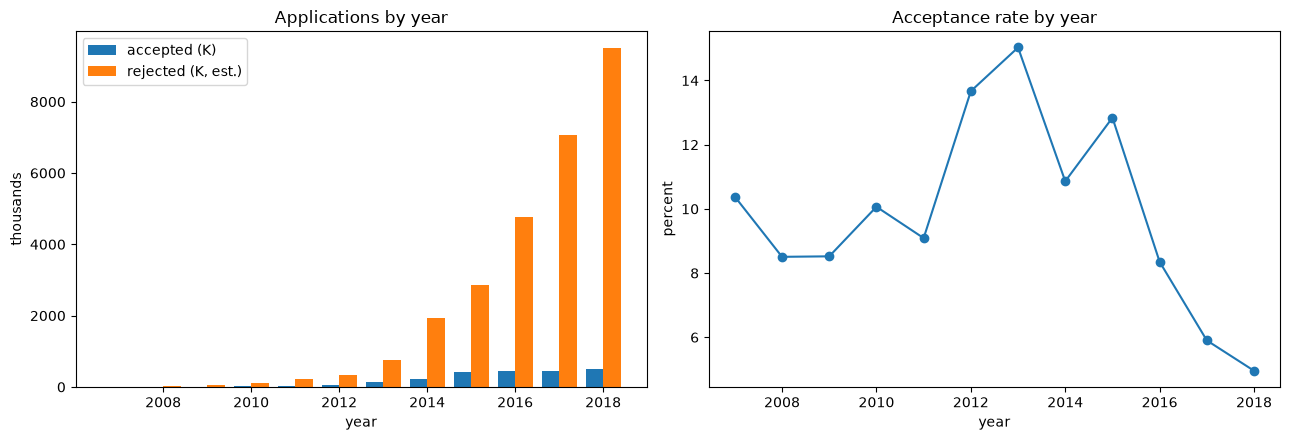

The acceptance rate is not a constant of nature — it is credit policy, and it moves. The pooled
acceptance rate (7.56%) the fitting notebook uses is a twelve-year average; the simulator treats it
as a stationary dial, which is a declared simplification (the simulated marketplace runs a 12-month window).


In [8]:
acc["year"] = acc["issue_d"].str[-4:].astype(int)
rej["year"] = rej["Application Date"].str[:4].astype(int)
acc_y = acc["year"].value_counts().sort_index()
rej_y = (rej["year"].value_counts().sort_index() / 0.15)  # scale the 15% sample to totals

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(acc_y.index - 0.2, acc_y.to_numpy() / 1e3, width=0.4, label="accepted (K)")
axes[0].bar(rej_y.index + 0.2, rej_y.to_numpy() / 1e3, width=0.4, label="rejected (K, est.)")
axes[0].set(title="Applications by year", xlabel="year", ylabel="thousands")
axes[0].legend()
rate_y = (acc_y / (acc_y + rej_y.reindex(acc_y.index).fillna(0))).dropna()
axes[1].plot(rate_y.index, rate_y.to_numpy() * 100, marker="o")
axes[1].set(title="Acceptance rate by year", xlabel="year", ylabel="percent")
fig.tight_layout()
plt.show()
print("The acceptance rate is not a constant of nature — it is credit policy, and it moves. "
      "The pooled\nacceptance rate (7.56%) the fitting notebook uses is a twelve-year "
      "average; the simulator treats it\nas a stationary dial, which is a declared "
      "simplification (the simulated marketplace runs a 12-month window).")


## 6. Business implications for Tributary, and declared assumptions

- **A lead marketplace's population is the applicant pool, not the funded pool.** Roughly 12
  of every 13 applicants here were declined. Simulating consumers from accepted-only data
  would produce an unrealistically pristine marketplace; C8's pooling is the corrective.
- **The accept/reject boundary is the quality signal.** The fitted acceptance model (AUC
  0.896) is the closest observable analog to "lead quality" — which is exactly what tier
  routing and floor prices key on in the waterfall.
- **The outcome columns are the Phase-5 payoff, not a Phase-1 input.** Post-origination
  fields power the simulated CRM's funded-loan outcomes later; using them to build
  application-time features would be leakage, and the census above marks the boundary.

Declared assumptions in this analysis:

1. Column-family assignment (Section 1) is by name pattern; the printed membership makes it
   auditable.
2. Rejected-file profiling uses a seeded 15% sample; totals cite the fitting artifact.
3. The acceptance rate is treated as stationary by the simulator (twelve-year pooled average)
   — a declared simplification of the visible vintage drift.
4. `Risk_Score` missingness is a recording-policy artifact, not applicant behavior, and the
   column is excluded from cross-file modeling.

Related: `01_lendingclub.ipynb` (the fits), `simulation/params/lendingclub_marginals.json`
(the artifact, including its data-mutation ledger), decisions C3, C8, INT-011.
